# EDA — Gold Table: NYC Urban Analytics
## `gold_nyc_urban` Exploratory Data Analysis

**MSBA 305 — Microsoft Fabric**

---

### What this notebook does
A structured exploration of the Gold table across 7 sections:

| Section | Focus |
|---|---|
| 1 | Table health — shape, nulls, dtypes, coverage |
| 2 | Univariate distributions — each variable on its own |
| 3 | Temporal patterns — time of day, day of week, month |
| 4 | Weather profile — categories, temperature, precipitation |
| 5 | Complaint patterns — volume, type, channel, status |
| 6 | Traffic patterns — volume, sensor coverage, availability |
| 7 | Bivariate relationships — weather × complaints × traffic |

All charts are produced with `matplotlib` and `seaborn` via `.toPandas()` on aggregated results —
never on the raw Spark DataFrame, so memory stays manageable.

---
## Cell 1 — Imports & Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql.window import Window

spark = SparkSession.builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

spark = SparkSession.builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

# ── Set default lakehouse ─────────────────────────────────────────────────────
LAKEHOUSE_NAME = "test_lakehouse_1"   # ← update if your lakehouse name differs

try:
    spark.sql(f"USE {LAKEHOUSE_NAME}")
    print(f"✅ Lakehouse set: {LAKEHOUSE_NAME}")
except Exception as e:
    try:
        spark.sql(f"USE CATALOG {LAKEHOUSE_NAME}")
        print(f"✅ Lakehouse set via CATALOG: {LAKEHOUSE_NAME}")
    except Exception as e2:
        print(f"⚠️  Could not set lakehouse: {e2}")
        print("   Manually attach the lakehouse in the left sidebar and re-run.")

GOLD_TABLE = "gold_nyc_urban"


# ── Plotting defaults ─────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi":       130,
    "figure.facecolor": "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})

# Borough colour map — consistent across all charts
BOROUGH_COLORS = {
    "Bronx":          "#e63946",
    "Brooklyn":       "#457b9d",
    "Manhattan":      "#2a9d8f",
    "Queens":         "#e9c46a",
    "Staten Island":  "#a8dadc",
}

WEATHER_COLORS = {
    "Clear":        "#f4d35e",
    "Cloudy":       "#8d99ae",
    "Rain":         "#457b9d",
    "Drizzle":      "#a8dadc",
    "Snow":         "#caf0f8",
    "Fog":          "#b5b5b5",
    "Thunderstorm": "#6a0572",
}

def section(title):
    print("\n" + "═" * 65)
    print(f"  {title}")
    print("═" * 65)



print("✅ Setup complete")

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 5, Finished, Available, Finished, False)

⚠️  Could not set lakehouse: 
[PARSE_SYNTAX_ERROR] Syntax error at or near 'test_lakehouse_1': extra input 'test_lakehouse_1'.(line 1, pos 12)

== SQL ==
USE CATALOG test_lakehouse_1
------------^^^

   Manually attach the lakehouse in the left sidebar and re-run.
✅ Setup complete


---
## Section 1 — Table Health
Before any analysis, verify the table is complete, well-formed, and coverage is as expected.

In [3]:
# ── 1a: Load and basic shape ──────────────────────────────────────────────────
section("1a — Basic Shape")

df = spark.table(GOLD_TABLE)
n_rows = df.count()
n_cols = len(df.columns)

print(f"  Rows    : {n_rows:,}")
print(f"  Columns : {n_cols}")
print(f"  Boroughs: {sorted([r[0] for r in df.select('borough').distinct().collect()])}")

time_range = df.agg(
    F.min("hour").alias("earliest"),
    F.max("hour").alias("latest")
).collect()[0]
print(f"  From    : {time_range['earliest']}")
print(f"  To      : {time_range['latest']}")
print()
df.printSchema()

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 6, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  1a — Basic Shape
═════════════════════════════════════════════════════════════════
  Rows    : 13,320
  Columns : 34
  Boroughs: ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']
  From    : 2026-01-01 00:00:00
  To      : 2026-04-21 23:00:00

root
 |-- borough: string (nullable = true)
 |-- hour: timestamp (nullable = true)
 |-- date: date (nullable = true)
 |-- day_of_week: string (nullable = true)
 |-- hour_of_day: integer (nullable = true)
 |-- is_weekend: boolean (nullable = true)
 |-- month: integer (nullable = true)
 |-- temperature_2m: double (nullable = true)
 |-- apparent_temperature: double (nullable = true)
 |-- precipitation: double (nullable = true)
 |-- rain: double (nullable = true)
 |-- snowfall_mm: double (nullable = true)
 |-- snow_depth: double (nullable = true)
 |-- wind_speed_10m: double (nullable = true)
 |-- wind_gusts_10m: double (nullable = true)
 |-- cloud_cover: double (nullable

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 7, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  1b — Null Audit
═════════════════════════════════════════════════════════════════
            column  null_count  null_pct
top_complaint_type         397       3.0

  Columns with zero nulls: 33


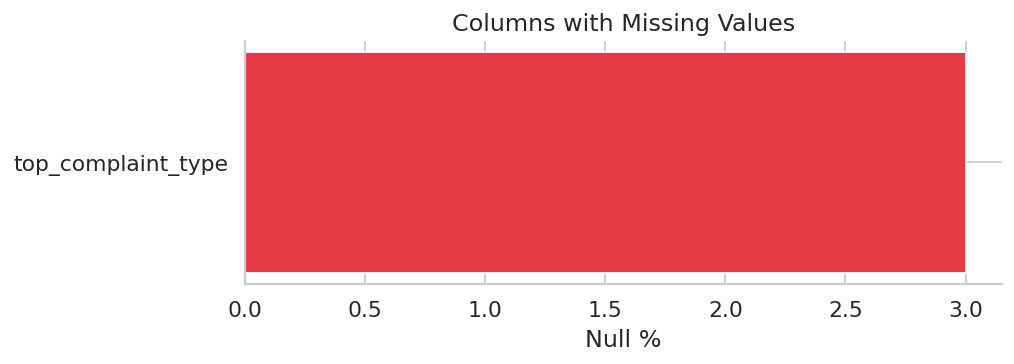

In [4]:
# ── 1b: Null audit — every column ────────────────────────────────────────────
section("1b — Null Audit")

null_exprs = [
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df.columns
]
null_counts = df.select(null_exprs).collect()[0].asDict()

null_df = pd.DataFrame([
    {"column": col, "null_count": cnt, "null_pct": round(100 * cnt / n_rows, 1)}
    for col, cnt in null_counts.items()
]).sort_values("null_pct", ascending=False)

print(null_df[null_df["null_count"] > 0].to_string(index=False))
print(f"\n  Columns with zero nulls: {(null_df['null_count'] == 0).sum()}")

# Chart: null % per column
has_nulls = null_df[null_df["null_count"] > 0]
if not has_nulls.empty:
    fig, ax = plt.subplots(figsize=(8, max(3, len(has_nulls) * 0.4)))
    ax.barh(has_nulls["column"], has_nulls["null_pct"], color="#e63946")
    ax.set_xlabel("Null %")
    ax.set_title("Columns with Missing Values")
    plt.tight_layout()
    plt.show()
else:
    print("\n  ✅ No nulls found in any column")

#### 1b — Insights 
- Only **one column has nulls**: `top_complaint_type` at 3%
- This is expected as those are hours where zero complaints were filed, so there is no dominant type
- All 33 other columns are fully populated 


StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 8, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  1c — Borough Coverage
═════════════════════════════════════════════════════════════════
      borough  total_hours   earliest              latest  unique_days  traffic_coverage_pct  complaint_coverage_pct
        Bronx         2664 2026-01-01 2026-04-21 23:00:00          111                  12.6                    97.3
     Brooklyn         2664 2026-01-01 2026-04-21 23:00:00          111                   6.3                    97.3
    Manhattan         2664 2026-01-01 2026-04-21 23:00:00          111                   6.3                    97.4
       Queens         2664 2026-01-01 2026-04-21 23:00:00          111                   0.9                    97.3
Staten Island         2664 2026-01-01 2026-04-21 23:00:00          111                   0.0                    95.7


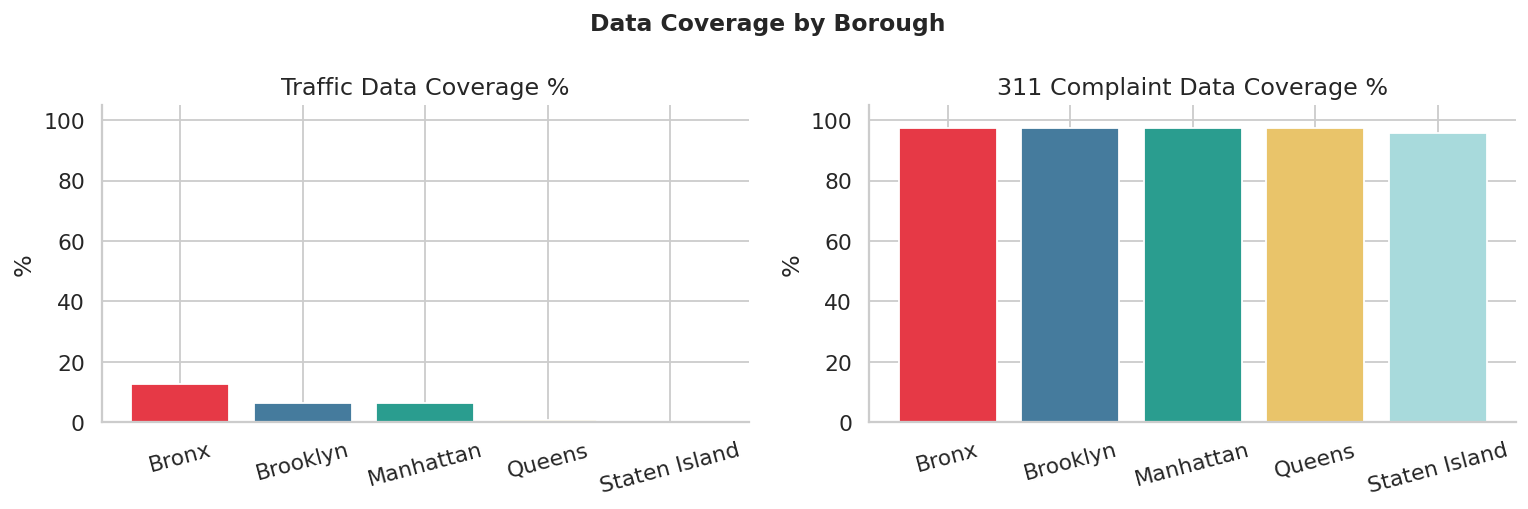

In [5]:
# ── 1c: Coverage by borough — rows, date range, traffic %, complaint % ────────
section("1c — Borough Coverage")

coverage = df.groupBy("borough").agg(
    F.count("*").alias("total_hours"),
    F.min("hour").alias("earliest"),
    F.max("hour").alias("latest"),
    F.countDistinct("date").alias("unique_days"),
    F.round(100 * F.avg(F.col("traffic_available").cast("int")), 1).alias("traffic_coverage_pct"),
    F.round(100 * F.avg(F.col("complaints_available").cast("int")), 1).alias("complaint_coverage_pct"),
).orderBy("borough").toPandas()

print(coverage.to_string(index=False))

# Chart: coverage comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = [BOROUGH_COLORS.get(b, "#aaa") for b in coverage["borough"]]

axes[0].bar(coverage["borough"], coverage["traffic_coverage_pct"], color=colors)
axes[0].set_title("Traffic Data Coverage %")
axes[0].set_ylabel("%")
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(coverage["borough"], coverage["complaint_coverage_pct"], color=colors)
axes[1].set_title("311 Complaint Data Coverage %")
axes[1].set_ylabel("%")
axes[1].set_ylim(0, 105)
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Data Coverage by Borough", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#### 1c — Insights
- **311 coverage is strong**: all 5 boroughs sit at ~97%, meaning almost every weather hour has complaint data
- **Traffic coverage is critically low**: Bronx 12.6%, Brooklyn 6.3%, Manhattan 6.3%, Queens and Staten Island near 0%
- This is a known data limitation, the NYC DOT API returned only 13 road segments for 2026

---
## Section 2 — Univariate Distributions
Each numeric variable independently — shape, range, skew.

In [6]:
# ── 2a: Descriptive stats for all numeric columns ─────────────────────────────
section("2a — Numeric Summary Statistics")

NUMERIC_COLS = [
    "temperature_2m", "apparent_temperature", "precipitation",
    "rain", "snowfall_mm", "wind_speed_10m", "wind_gusts_10m",
    "cloud_cover", "traffic_volume", "sensor_count",
    "complaint_count", "noise_complaints", "street_complaints",
    "heat_hot_water_complaints",
    "num_open_complaints", "num_closed_complaints",
    "num_complaints_mobile", "num_complaints_online", "num_complaints_phone",
]

existing_numeric = [c for c in NUMERIC_COLS if c in df.columns]

stats_pd = df.select(existing_numeric).describe().toPandas()
stats_pd = stats_pd.set_index("summary").T
stats_pd = stats_pd.apply(pd.to_numeric, errors="coerce").round(2)
print(stats_pd.to_string())

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 9, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  2a — Numeric Summary Statistics
═════════════════════════════════════════════════════════════════
summary                    count   mean  stddev   min      max
temperature_2m             13320   2.96    8.97 -18.3    33.40
apparent_temperature       13320  -0.79   10.26 -24.6    34.10
precipitation              13320   0.10    0.42   0.0    10.10
rain                       13320   0.06    0.35   0.0    10.10
snowfall_mm                13320   0.00    0.02   0.0     0.35
wind_speed_10m             13320  11.49    5.86   0.0    41.90
wind_gusts_10m             13320  27.00   13.34   1.4    95.40
cloud_cover                13320  60.62   43.27   0.0   100.00
traffic_volume             13320  25.99  145.56   0.0  1665.00
sensor_count               13320   0.17    0.79   0.0     4.00
complaint_count            13320  87.50   65.21   0.0   608.00
noise_complaints           13320  13.59   14.60   0.0   154.00
street_complai

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 10, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  2b — Weather Variable Distributions
═════════════════════════════════════════════════════════════════


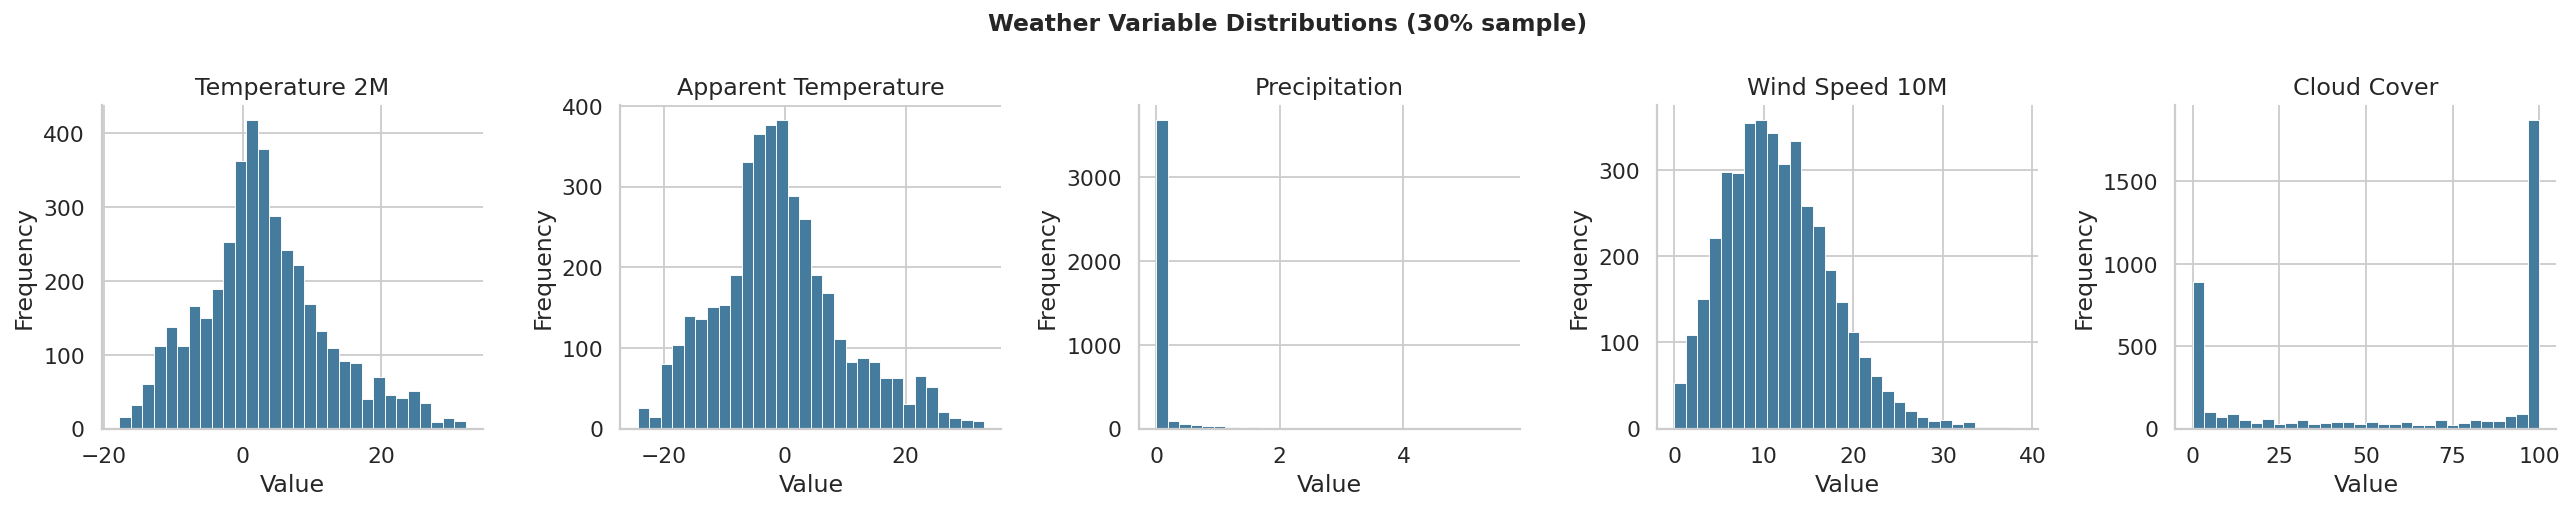

In [7]:
# ── 2b: Distribution histograms — weather variables ───────────────────────────
section("2b — Weather Variable Distributions")

weather_vars = ["temperature_2m", "apparent_temperature",
                "precipitation", "wind_speed_10m", "cloud_cover"]
weather_vars = [c for c in weather_vars if c in df.columns]

# Sample for plotting — 5000 rows is enough for distribution shape
sample_pd = df.select(weather_vars).sample(fraction=0.3, seed=42).toPandas()

fig, axes = plt.subplots(1, len(weather_vars), figsize=(4 * len(weather_vars), 4))
for ax, col in zip(axes, weather_vars):
    ax.hist(sample_pd[col].dropna(), bins=30, color="#457b9d", edgecolor="white", linewidth=0.5)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.suptitle("Weather Variable Distributions (30% sample)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#### 2b — Insights
- **Temperature** is roughly bell-shaped, centred around 0–5°C which is expected for a Jan–Apr NYC window
- **Precipitation** is heavily right-skewed where the vast majority of hours have zero or near-zero rain
- **Wind speed** is mildly right-skewed: most hours are calm, with occasional gusty outliers
- **Cloud cover** shows a bimodal pattern: hours tend to be either mostly clear or fully overcast, rarely in between

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 11, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  2c — Complaint Count Distribution
═════════════════════════════════════════════════════════════════


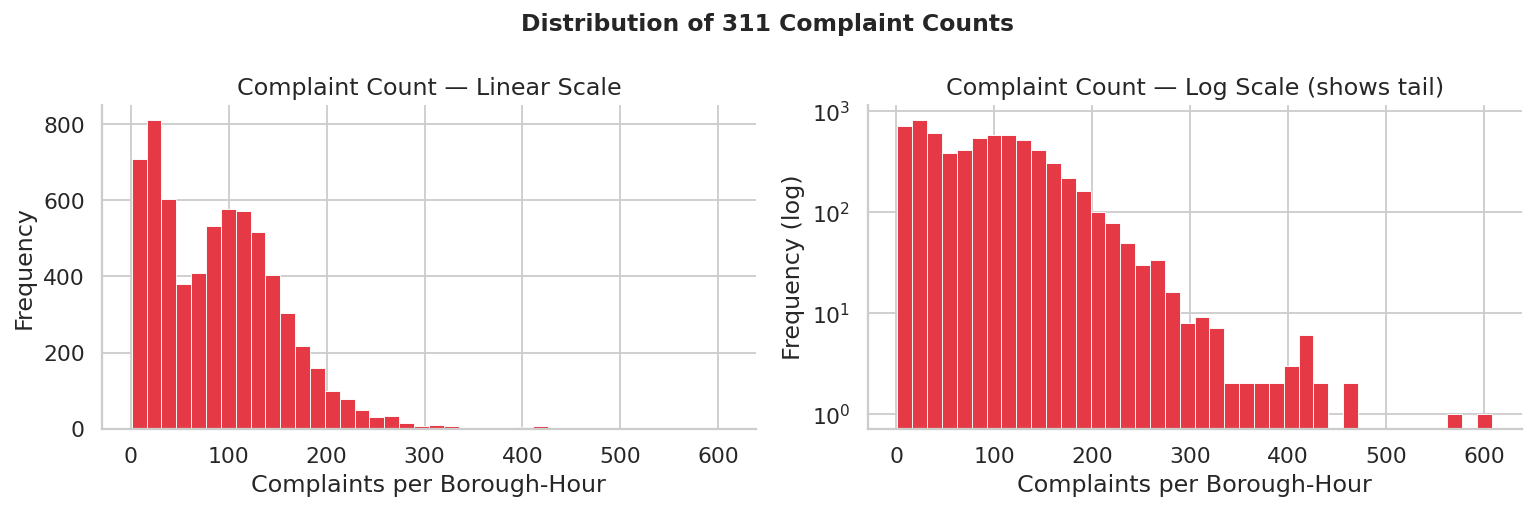

  Median complaints/hour : 87
  Mean complaints/hour   : 90.9
  95th percentile        : 202
  Max                    : 608


In [8]:
# ── 2c: Complaint count distribution — log scale to handle skew ───────────────
section("2c — Complaint Count Distribution")

complaint_sample = (
    df.filter(F.col("complaints_available") == True)
      .select("complaint_count")
      .sample(fraction=0.5, seed=42)
      .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
axes[0].hist(complaint_sample["complaint_count"], bins=40,
             color="#e63946", edgecolor="white", linewidth=0.5)
axes[0].set_title("Complaint Count — Linear Scale")
axes[0].set_xlabel("Complaints per Borough-Hour")
axes[0].set_ylabel("Frequency")

# Log scale — better shows the tail
axes[1].hist(complaint_sample["complaint_count"], bins=40,
             color="#e63946", edgecolor="white", linewidth=0.5, log=True)
axes[1].set_title("Complaint Count — Log Scale (shows tail)")
axes[1].set_xlabel("Complaints per Borough-Hour")
axes[1].set_ylabel("Frequency (log)")

plt.suptitle("Distribution of 311 Complaint Counts", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"  Median complaints/hour : {complaint_sample['complaint_count'].median():.0f}")
print(f"  Mean complaints/hour   : {complaint_sample['complaint_count'].mean():.1f}")
print(f"  95th percentile        : {complaint_sample['complaint_count'].quantile(0.95):.0f}")
print(f"  Max                    : {complaint_sample['complaint_count'].max():,}")

#### 2c — Insights
- Complaint counts are **right-skewed**: median is 87/hour but the mean is pulled to 91 by the tail
- The 95th percentile is 202, meaning extreme hours (200+ complaints) are real but uncommon
- The max of 608 complaints in a single borough-hour represents a genuine spike event


---
## Section 3 — Temporal Patterns
How do complaints and traffic vary by hour, day, and month?

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 12, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  3a — Hourly Rhythm
═════════════════════════════════════════════════════════════════


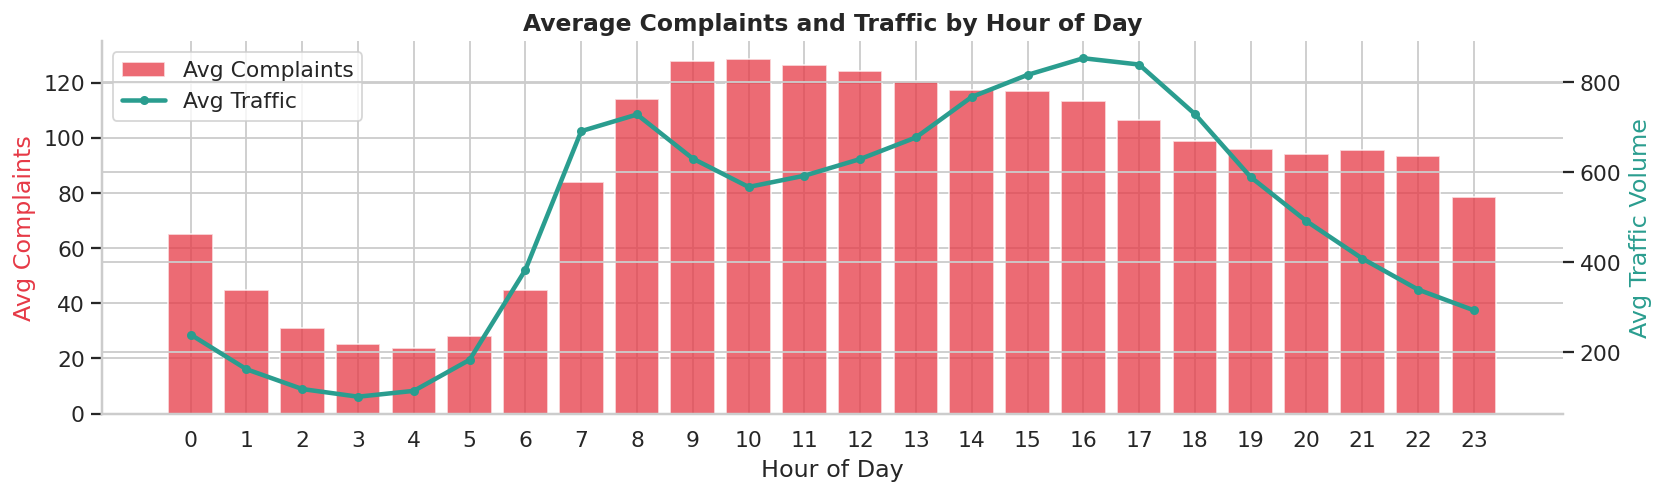

In [9]:
# ── 3a: Hourly rhythm — complaints and traffic by hour of day ─────────────────
section("3a — Hourly Rhythm")

hourly = (
    df.groupBy("hour_of_day")
      .agg(
          F.round(F.avg("complaint_count"), 1).alias("avg_complaints"),
          F.round(F.avg(
              F.when(F.col("traffic_available") == True, F.col("traffic_volume"))
          ), 0).alias("avg_traffic"),
      )
      .orderBy("hour_of_day")
      .toPandas()
)

fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()

ax1.bar(hourly["hour_of_day"], hourly["avg_complaints"],
        color="#e63946", alpha=0.75, label="Avg Complaints")
ax2.plot(hourly["hour_of_day"], hourly["avg_traffic"],
         color="#2a9d8f", linewidth=2.5, marker="o", markersize=4, label="Avg Traffic")

ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Avg Complaints", color="#e63946")
ax2.set_ylabel("Avg Traffic Volume", color="#2a9d8f")
ax1.set_xticks(range(0, 24))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Average Complaints and Traffic by Hour of Day", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#### 3a — Insights
- Complaints follow a clear **daily rhythm**: low overnight (midnight–6am), rising through the morning, peaking in the afternoon and early evening
- The two curves move **together**, suggesting complaints are partly driven by how many people are active
- Lowest complaint hours: 2–5am. Peak complaint hours: 9am–12pm

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 13, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  3b — Weekday vs Weekend Hourly Profile
═════════════════════════════════════════════════════════════════


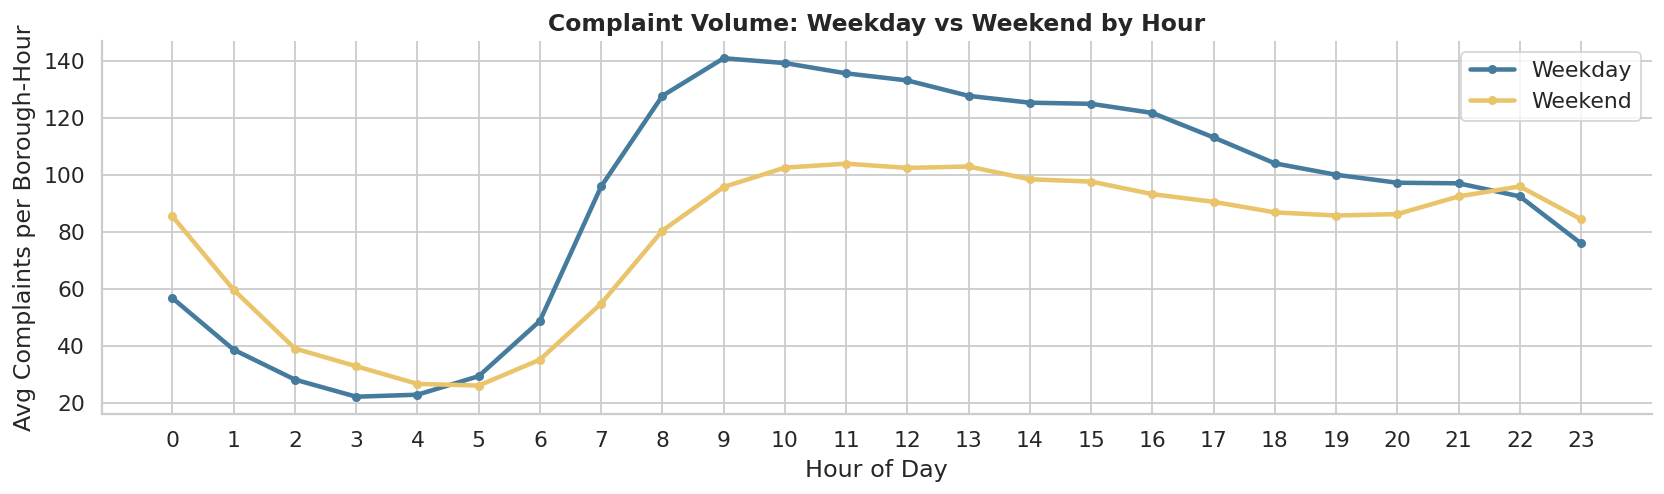

In [10]:
# ── 3b: Weekday vs weekend — complaints by hour ───────────────────────────────
section("3b — Weekday vs Weekend Hourly Profile")

DOW_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

hourly_wk = (
    df.groupBy("hour_of_day", "is_weekend")
      .agg(F.round(F.avg("complaint_count"), 1).alias("avg_complaints"))
      .orderBy("is_weekend", "hour_of_day")
      .toPandas()
)

fig, ax = plt.subplots(figsize=(13, 4))

for is_wk, label, color in [(0, "Weekday", "#457b9d"), (1, "Weekend", "#e9c46a")]:
    subset = hourly_wk[hourly_wk["is_weekend"] == is_wk]
    ax.plot(subset["hour_of_day"], subset["avg_complaints"],
            label=label, color=color, linewidth=2.5, marker="o", markersize=4)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Avg Complaints per Borough-Hour")
ax.set_xticks(range(0, 24))
ax.legend()
plt.title("Complaint Volume: Weekday vs Weekend by Hour", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#### 3b — Insights
- Weekend complaints are higher than weekday in the late night and early morning (10pm–3am)
- Weekdays peak more sharply in the afternoon (2–6pm) likely driven by commute and daytime activity
- This pattern is consistent with noise complaints as weekend nights are louder

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 14, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  3c — Complaint Heatmap: Hour × Day of Week
═════════════════════════════════════════════════════════════════


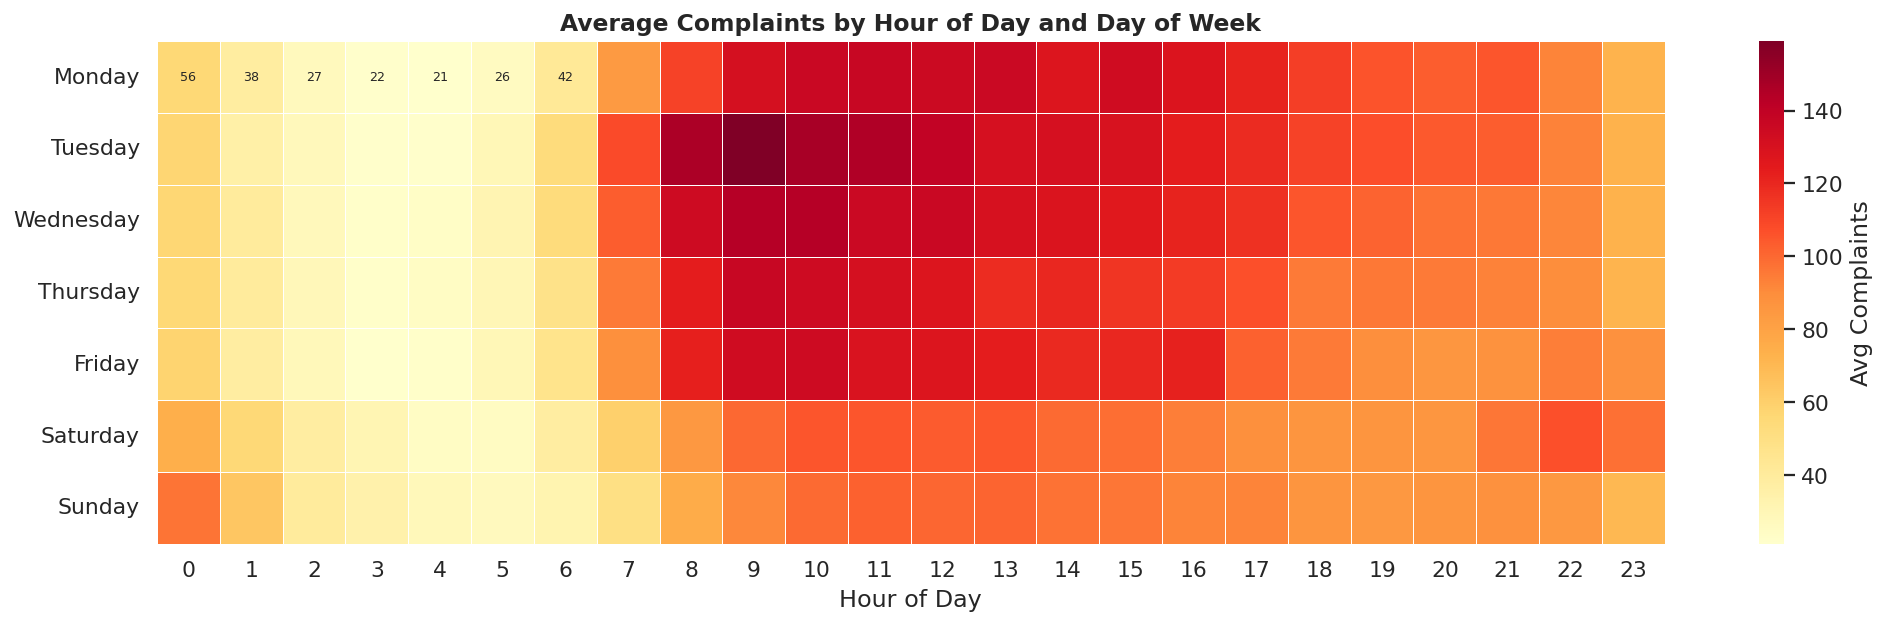

In [11]:
# ── 3c: Heatmap — complaints by hour of day × day of week ────────────────────
section("3c — Complaint Heatmap: Hour × Day of Week")

DOW_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

heatmap_data = (
    df.groupBy("hour_of_day", "day_of_week")
      .agg(F.round(F.avg("complaint_count"), 1).alias("avg_complaints"))
      .toPandas()
)

pivot = heatmap_data.pivot(index="day_of_week", columns="hour_of_day", values="avg_complaints")
pivot = pivot.reindex(DOW_ORDER)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot, ax=ax,
    cmap="YlOrRd",
    linewidths=0.3,
    annot=True, fmt=".0f", annot_kws={"size": 7},
    cbar_kws={"label": "Avg Complaints"}
)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("")
plt.title("Average Complaints by Hour of Day and Day of Week", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#### 3c — Insights
- The heatmap confirms complaints are **highest on 9am**, but strangely on Tusedays.
- Mornings (5–6am) are consistently the quietest across all days
- Complaint volume is as much about social behaviour as it is about weather

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 41, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  3d — Monthly Trend
═════════════════════════════════════════════════════════════════


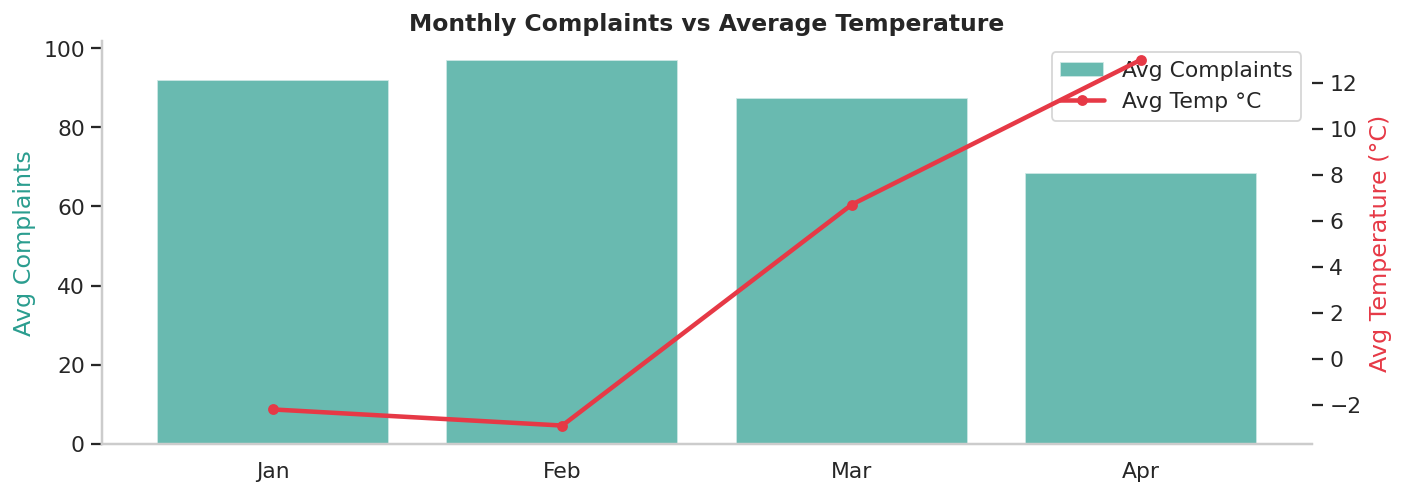

In [28]:
# ── 3d: Monthly trend — complaints and temperature ────────────────────────────
section("3d — Monthly Trend")

monthly = (
    df.groupBy("month")
      .agg(
          F.round(F.avg("complaint_count"), 1).alias("avg_complaints"),
          F.round(F.avg("temperature_2m"), 1).alias("avg_temp_c"),
          F.round(F.avg("precipitation"), 2).alias("avg_precip_mm"),
          F.count("*").alias("hours"),
      )
      .orderBy("month")
      .toPandas()
)

MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly["month_label"] = monthly["month"].apply(lambda m: MONTH_LABELS[m-1])

fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()

ax1.bar(monthly["month_label"], monthly["avg_complaints"],
        color="#2a9d8f", alpha=0.7, label="Avg Complaints")
ax2.plot(monthly["month_label"], monthly["avg_temp_c"],
         color="#e63946", linewidth=2.5, marker="o", markersize=5, label="Avg Temp °C")

ax1.set_ylabel("Avg Complaints", color="#2a9d8f")
ax2.set_ylabel("Avg Temperature (°C)", color="#e63946")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.grid(False)
ax2.grid(False)

plt.title("Monthly Complaints vs Average Temperature", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#### 3d — Insights
- Complaints are **inversely related to temperature** — January and February (coldest months) show the highest rates
- As temperature rises toward April, complaints decline slightly
- This aligns with the heat/hot water complaint signal: cold months drive housing-related complaints
- The dataset only covers Jan to Apr so summer patterns (heat waves, outdoor noise) are not yet visible

---
## Section 4 — Weather Profile
How is weather distributed across the dataset? What does a typical NYC hour look like?

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 16, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  4a — Weather Category Distribution
═════════════════════════════════════════════════════════════════
weather_category  count  pct
           Clear  11681 87.7
         Drizzle    819  6.1
            Snow    615  4.6
            Rain    205  1.5


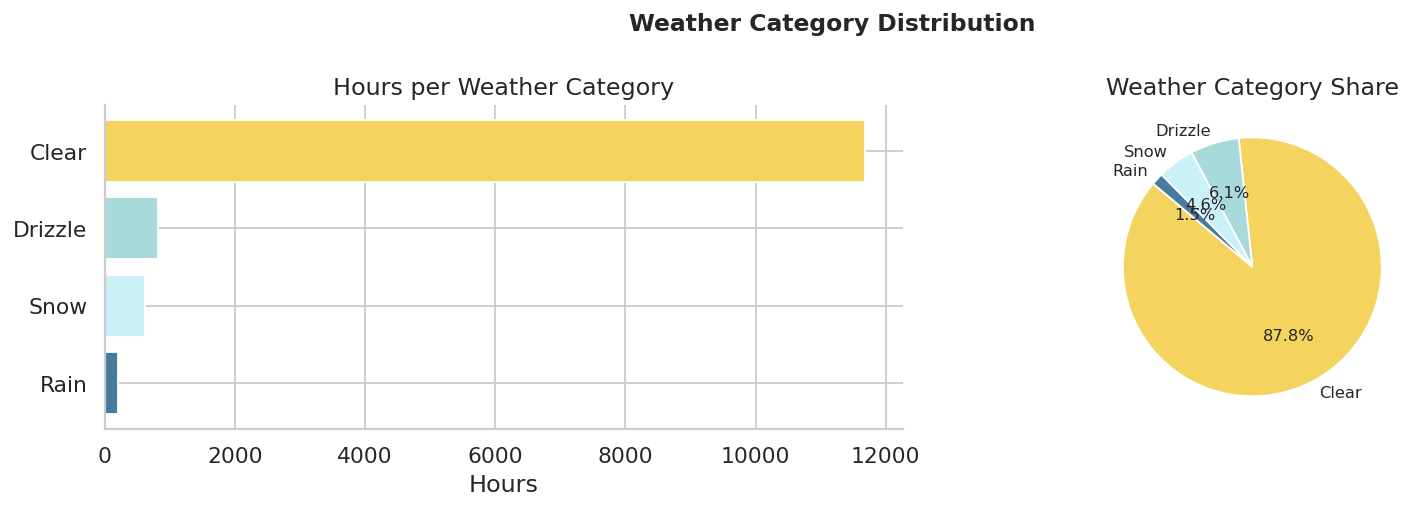

In [13]:
# ── 4a: Weather category distribution ────────────────────────────────────────
section("4a — Weather Category Distribution")

wcat = (
    df.groupBy("weather_category")
      .count()
      .withColumn("pct", F.round(100 * F.col("count") / n_rows, 1))
      .orderBy(F.desc("count"))
      .toPandas()
)

print(wcat.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = [WEATHER_COLORS.get(w, "#aaa") for w in wcat["weather_category"]]

axes[0].barh(wcat["weather_category"], wcat["count"], color=colors)
axes[0].set_xlabel("Hours")
axes[0].set_title("Hours per Weather Category")
axes[0].invert_yaxis()

axes[1].pie(
    wcat["pct"], labels=wcat["weather_category"],
    colors=colors, autopct="%1.1f%%", startangle=140,
    textprops={"fontsize": 9}
)
axes[1].set_title("Weather Category Share")

plt.suptitle("Weather Category Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 17, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  4b — Temperature by Borough
═════════════════════════════════════════════════════════════════


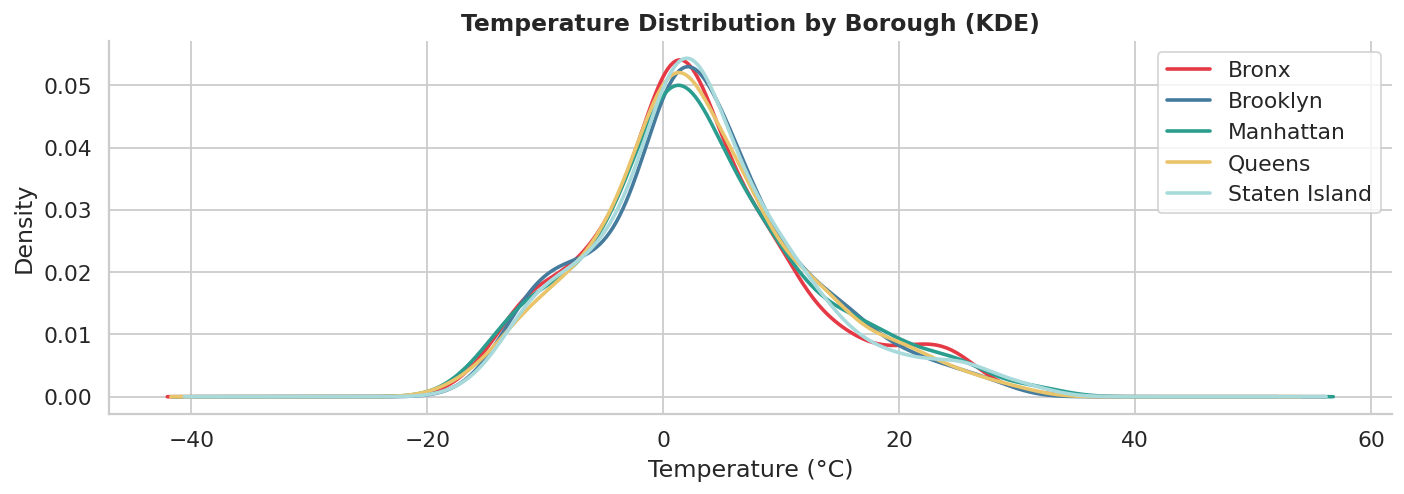

In [14]:
# ── 4b: Temperature distribution by borough ───────────────────────────────────
section("4b — Temperature by Borough")

temp_pd = df.select("borough", "temperature_2m").sample(fraction=0.3, seed=42).toPandas()

fig, ax = plt.subplots(figsize=(11, 4))
for borough, color in BOROUGH_COLORS.items():
    subset = temp_pd[temp_pd["borough"] == borough]["temperature_2m"].dropna()
    if not subset.empty:
        subset.plot.kde(ax=ax, label=borough, color=color, linewidth=2)

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Density")
ax.legend()
plt.title("Temperature Distribution by Borough (KDE)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
# Note: KDE curves should be nearly identical across boroughs —
# weather stations are close together. Large divergence = data issue.

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 18, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  4c — Precipitation Profile
═════════════════════════════════════════════════════════════════
  Dry (0mm)          : 87.7% of hours
  Light (0–2mm)      : 11.1% of hours
  Moderate (2–10mm)  : 1.2% of hours
  Heavy (>10mm)      : 0.0% of hours


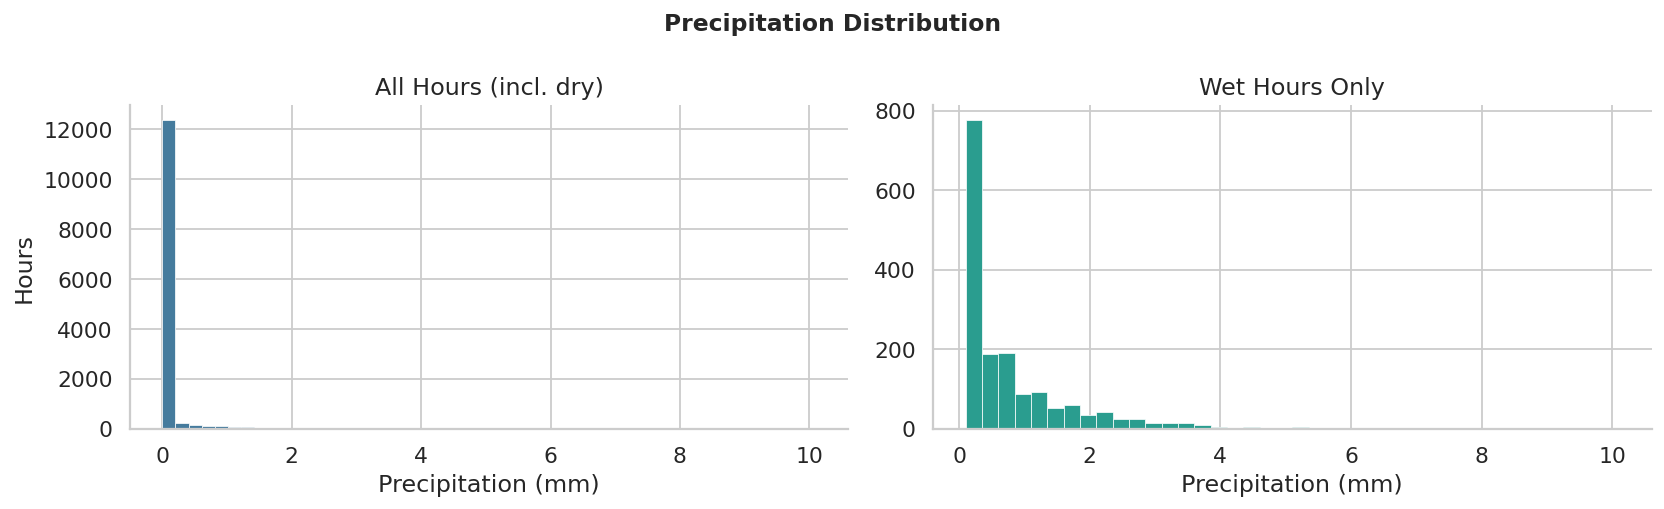

In [15]:
# ── 4c: Precipitation — how often does it rain, and how hard? ────────────────
section("4c — Precipitation Profile")

precip_pd = df.select("precipitation", "weather_category").toPandas()

dry_pct   = round(100 * (precip_pd["precipitation"] == 0).sum() / len(precip_pd), 1)
light_pct = round(100 * ((precip_pd["precipitation"] > 0) & (precip_pd["precipitation"] <= 2)).sum() / len(precip_pd), 1)
mod_pct   = round(100 * ((precip_pd["precipitation"] > 2) & (precip_pd["precipitation"] <= 10)).sum() / len(precip_pd), 1)
heavy_pct = round(100 * (precip_pd["precipitation"] > 10).sum() / len(precip_pd), 1)

print(f"  Dry (0mm)          : {dry_pct}% of hours")
print(f"  Light (0–2mm)      : {light_pct}% of hours")
print(f"  Moderate (2–10mm)  : {mod_pct}% of hours")
print(f"  Heavy (>10mm)      : {heavy_pct}% of hours")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# All precipitation (including 0)
axes[0].hist(precip_pd["precipitation"], bins=50,
             color="#457b9d", edgecolor="white", linewidth=0.4)
axes[0].set_xlabel("Precipitation (mm)")
axes[0].set_ylabel("Hours")
axes[0].set_title("All Hours (incl. dry)")

# Non-zero only
wet = precip_pd[precip_pd["precipitation"] > 0]["precipitation"]
axes[1].hist(wet, bins=40, color="#2a9d8f", edgecolor="white", linewidth=0.4)
axes[1].set_xlabel("Precipitation (mm)")
axes[1].set_title("Wet Hours Only")

plt.suptitle("Precipitation Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#### 4c — Insights
- **87.7% of hours had zero precipitation** 
- Of the wet hours, most fall in the light range (0–2mm)
- Heavy precipitation (>10mm) effectively did not occur in this period
- Conclusions about rain effects in this dataset are really about light drizzle and not storms

---
## Section 5 — Complaint Patterns
Volume, type breakdown, channels, and status.

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 19, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  5a — Complaint Volume by Borough
═════════════════════════════════════════════════════════════════
      borough  total_complaints  avg_per_hour  peak_hour
     Brooklyn            356228         137.4        608
       Queens            284089         109.6        458
        Bronx            248043          95.7        294
    Manhattan            221777          85.5        299
Staten Island             55408          21.7        484


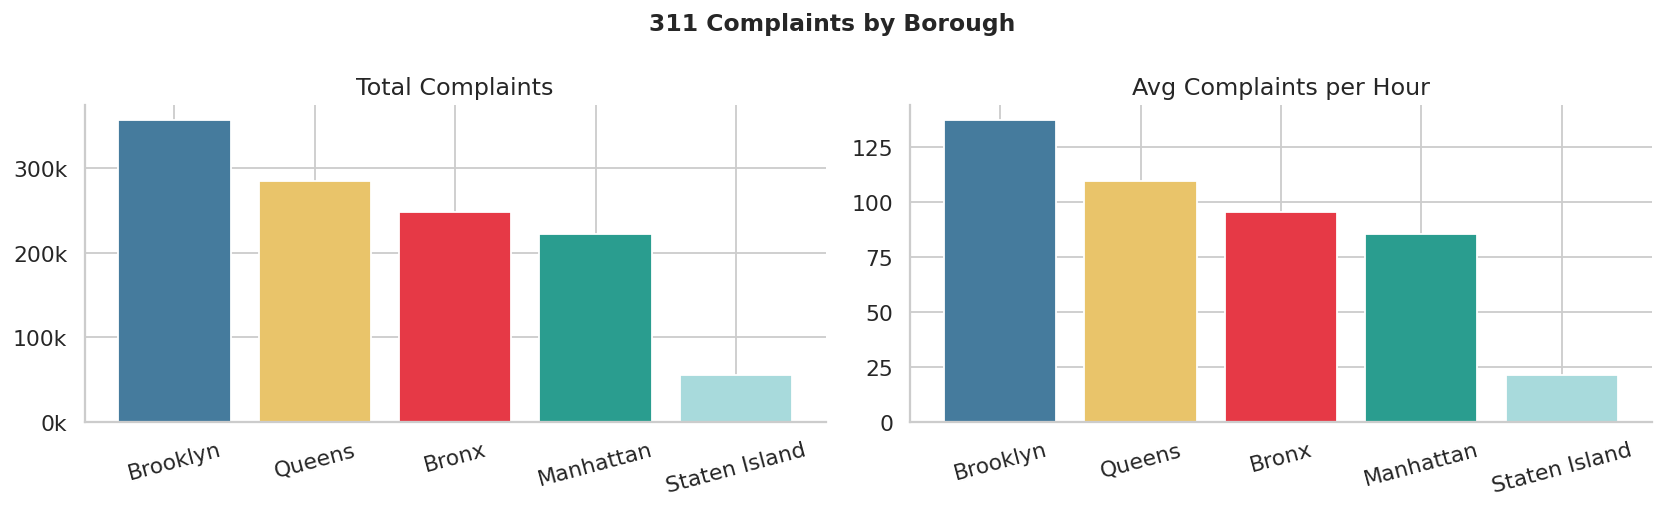

In [16]:
# ── 5a: Total complaints per borough ─────────────────────────────────────────
section("5a — Complaint Volume by Borough")

borough_complaints = (
    df.filter(F.col("complaints_available") == True)
      .groupBy("borough")
      .agg(
          F.sum("complaint_count").alias("total_complaints"),
          F.round(F.avg("complaint_count"), 1).alias("avg_per_hour"),
          F.max("complaint_count").alias("peak_hour"),
      )
      .orderBy(F.desc("total_complaints"))
      .toPandas()
)

print(borough_complaints.to_string(index=False))

colors = [BOROUGH_COLORS.get(b, "#aaa") for b in borough_complaints["borough"]]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(borough_complaints["borough"], borough_complaints["total_complaints"],
            color=colors)
axes[0].set_title("Total Complaints")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(borough_complaints["borough"], borough_complaints["avg_per_hour"],
            color=colors)
axes[1].set_title("Avg Complaints per Hour")
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("311 Complaints by Borough", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#### 5a — Insights
- **Brooklyn generates the most complaints** which makes sense since it is the busiest, and has the largest population
- **Staten Island** is far lower (55k, 22/hr) mostly due to population size

- Brooklyn's peak of 608 complaints in one hour is the dataset maximum

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 20, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  5b — Complaint Type Buckets by Borough
═════════════════════════════════════════════════════════════════


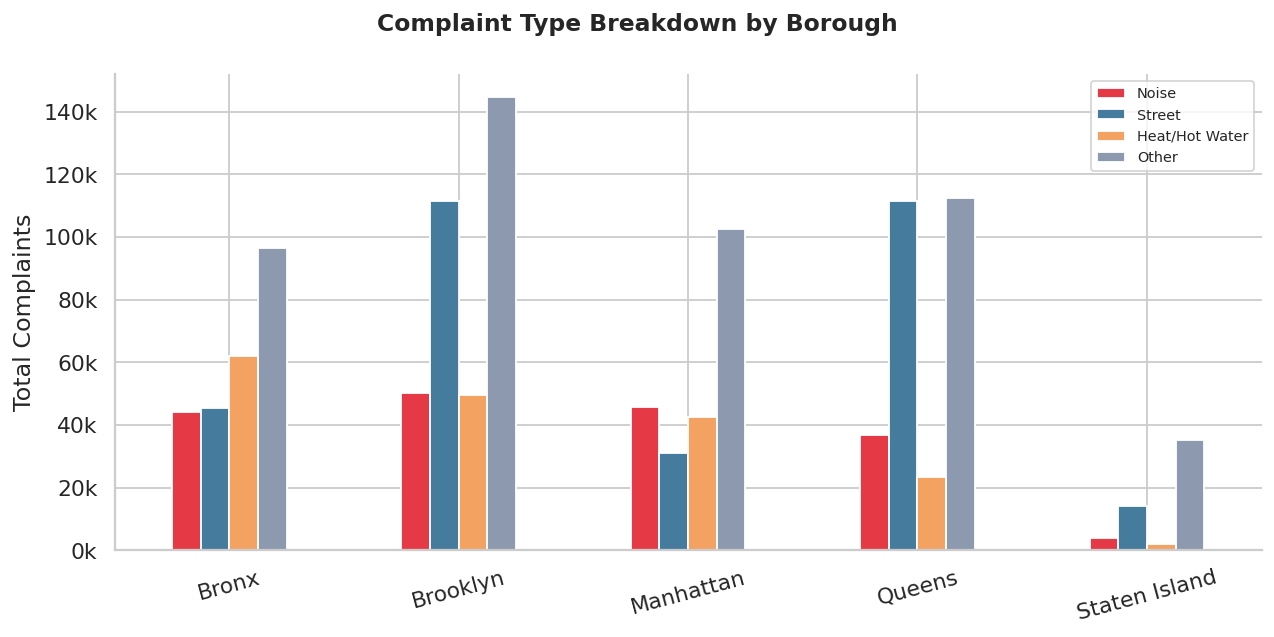

In [17]:
# ── 5b: Complaint type buckets by borough ─────────────────────────────────────
section("5b — Complaint Type Buckets by Borough")

buckets = (
    df.filter(F.col("complaints_available") == True)
      .groupBy("borough")
      .agg(
          F.sum("noise_complaints").alias("Noise"),
          F.sum("street_complaints").alias("Street"),
          F.sum("heat_hot_water_complaints").alias("Heat/Hot Water"),
          F.sum("other_complaints").alias("Other"),
      )
      .orderBy("borough")
      .toPandas()
      .set_index("borough")
)

bucket_colors = ["#e63946", "#457b9d", "#f4a261", "#8d99ae"]

fig, ax = plt.subplots(figsize=(10, 5))
buckets.plot(kind="bar", ax=ax, color=bucket_colors, edgecolor="white")
ax.set_ylabel("Total Complaints")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
ax.legend(loc="upper right", fontsize=8)

plt.suptitle("Complaint Type Breakdown by Borough", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 21, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  5c — Channel Mix and Status
═════════════════════════════════════════════════════════════════


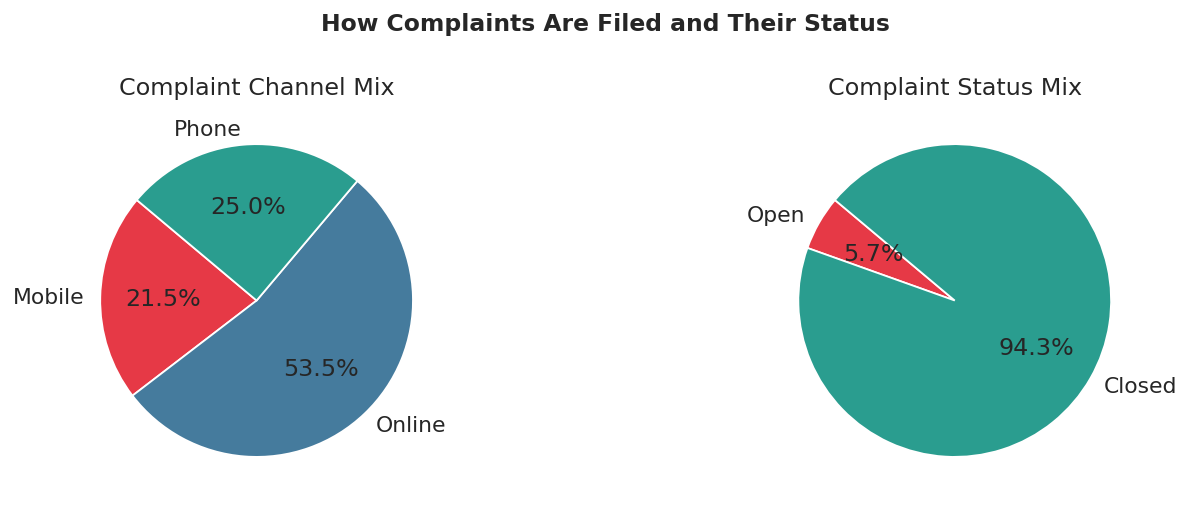

In [18]:
# ── 5c: Channel mix and open vs closed ───────────────────────────────────────
section("5c — Channel Mix and Status")

channels = (
    df.filter(F.col("complaints_available") == True)
      .agg(
          F.sum("num_complaints_mobile").alias("Mobile"),
          F.sum("num_complaints_online").alias("Online"),
          F.sum("num_complaints_phone").alias("Phone"),
          F.sum("num_open_complaints").alias("Open"),
          F.sum("num_closed_complaints").alias("Closed"),
      )
      .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

channel_vals = channels[["Mobile", "Online", "Phone"]].values.flatten()
axes[0].pie(channel_vals, labels=["Mobile", "Online", "Phone"],
            colors=["#e63946", "#457b9d", "#2a9d8f"],
            autopct="%1.1f%%", startangle=140)
axes[0].set_title("Complaint Channel Mix")

status_vals = channels[["Open", "Closed"]].values.flatten()
axes[1].pie(status_vals, labels=["Open", "Closed"],
            colors=["#e63946", "#2a9d8f"],
            autopct="%1.1f%%", startangle=140)
axes[1].set_title("Complaint Status Mix")

plt.suptitle("How Complaints Are Filed and Their Status", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 22, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  5d — Top 15 Complaint Types
═════════════════════════════════════════════════════════════════


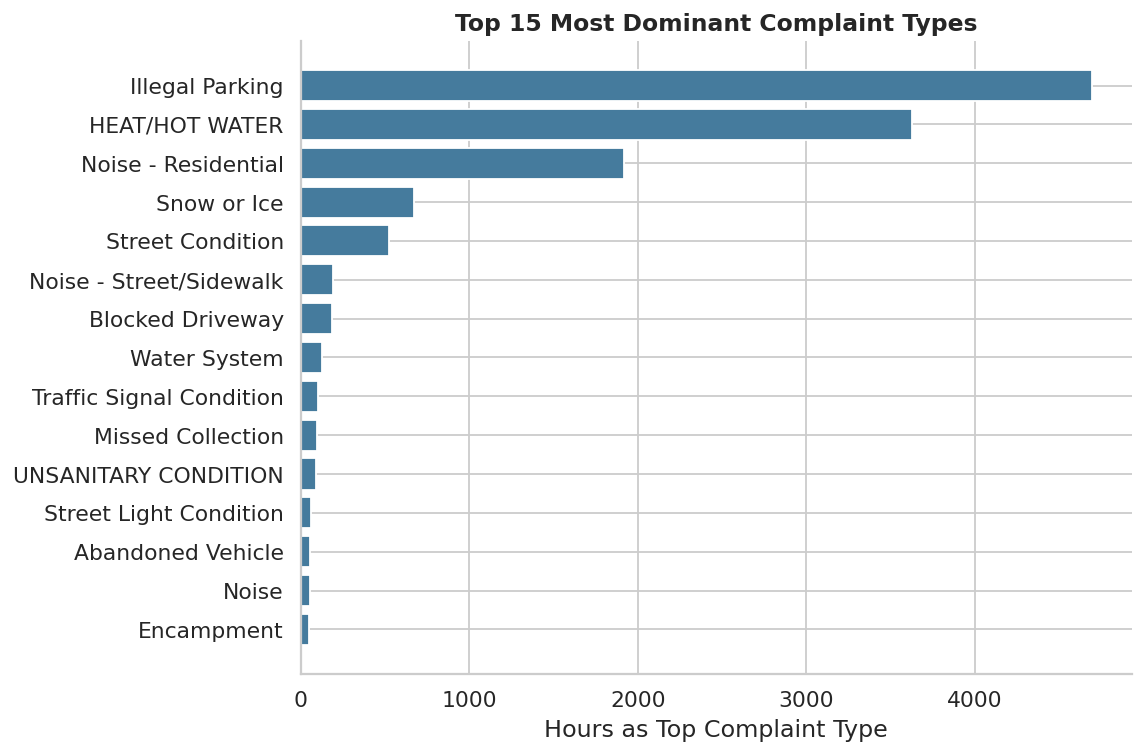

In [19]:
# ── 5d: Top complaint types overall ──────────────────────────────────────────
section("5d — Top 15 Complaint Types")

top_types = (
    df.filter(
        (F.col("complaints_available") == True) &
        (F.col("top_complaint_type").isNotNull())
    )
    .groupBy("top_complaint_type")
    .agg(F.count("*").alias("hours_as_top"))
    .orderBy(F.desc("hours_as_top"))
    .limit(15)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_types["top_complaint_type"][::-1],
        top_types["hours_as_top"][::-1],
        color="#457b9d")
ax.set_xlabel("Hours as Top Complaint Type")
ax.set_title("Top 15 Most Dominant Complaint Types", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 23, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  5e — Top Agencies by Complaint Volume
═════════════════════════════════════════════════════════════════
label  complaint_count
 NYPD           453414
  HPD           345704
 DSNY           132150
  DOT            88048
  DEP            56308
  DOB            23328
  DPR            22258
DOHMH            17452
  DHS            10717
  TLC            10636
 DCWP             5530


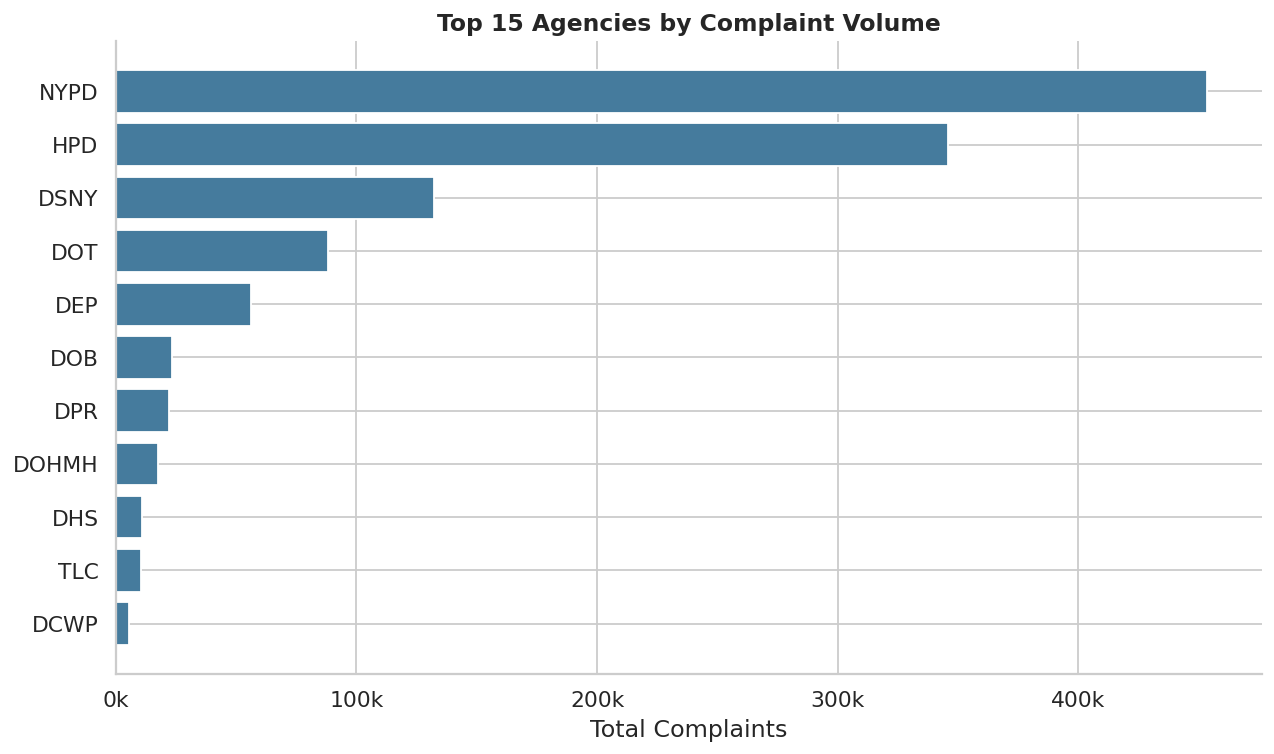

In [20]:
# ── 5e: Top agencies handling complaints ──────────────────────────────────────
section("5e — Top Agencies by Complaint Volume")

# Pull from silver_stg_311 directly — agency is not aggregated into Gold
# so we go back to the source for this one
df_311 = spark.table("silver_stg_nyc_311")

top_agencies = (
    df_311
    .filter(F.col("agency_name").isNotNull())
    .groupBy("agency", "agency_name")
    .agg(F.count("*").alias("complaint_count"))
    .orderBy(F.desc("complaint_count"))
    .limit(15)
    .toPandas()
)

# Combine agency code + name for a readable label
top_agencies["label"] = top_agencies["agency"]
print(top_agencies[["label", "complaint_count"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    top_agencies["label"][::-1],
    top_agencies["complaint_count"][::-1],
    color="#457b9d"
)
ax.set_xlabel("Total Complaints")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
ax.set_title("Top 15 Agencies by Complaint Volume", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Section 6 — Traffic Patterns

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 24, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  6a — Traffic Volume by Borough
═════════════════════════════════════════════════════════════════
  borough  avg_hourly_volume  peak_volume  avg_sensors  hours_with_data
   Queens             1025.0         1665          4.0               24
 Brooklyn              720.0         1343          4.0              168
    Bronx              551.0         1494          4.0              336
Manhattan               92.0          248          1.0              168


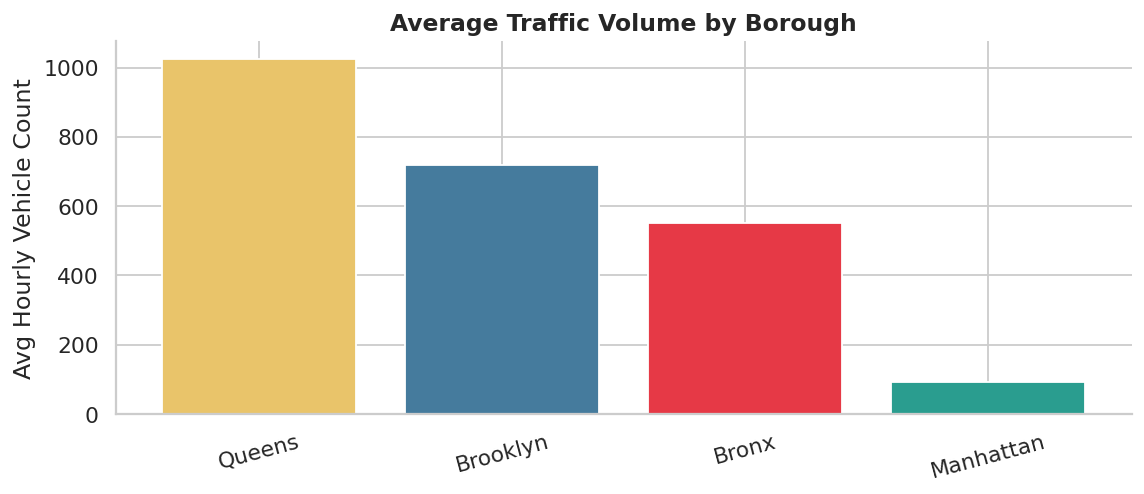

In [21]:
# ── 6a: Traffic volume by borough ────────────────────────────────────────────
section("6a — Traffic Volume by Borough")

traffic_borough = (
    df.filter(F.col("traffic_available") == True)
      .groupBy("borough")
      .agg(
          F.round(F.avg("traffic_volume"), 0).alias("avg_hourly_volume"),
          F.max("traffic_volume").alias("peak_volume"),
          F.round(F.avg("sensor_count"), 1).alias("avg_sensors"),
          F.count("*").alias("hours_with_data"),
      )
      .orderBy(F.desc("avg_hourly_volume"))
      .toPandas()
)

print(traffic_borough.to_string(index=False))

colors = [BOROUGH_COLORS.get(b, "#aaa") for b in traffic_borough["borough"]]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(traffic_borough["borough"], traffic_borough["avg_hourly_volume"], color=colors)
ax.set_ylabel("Avg Hourly Vehicle Count")
ax.set_title("Average Traffic Volume by Borough", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 25, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  6b — Traffic Volume by Hour of Day
═════════════════════════════════════════════════════════════════


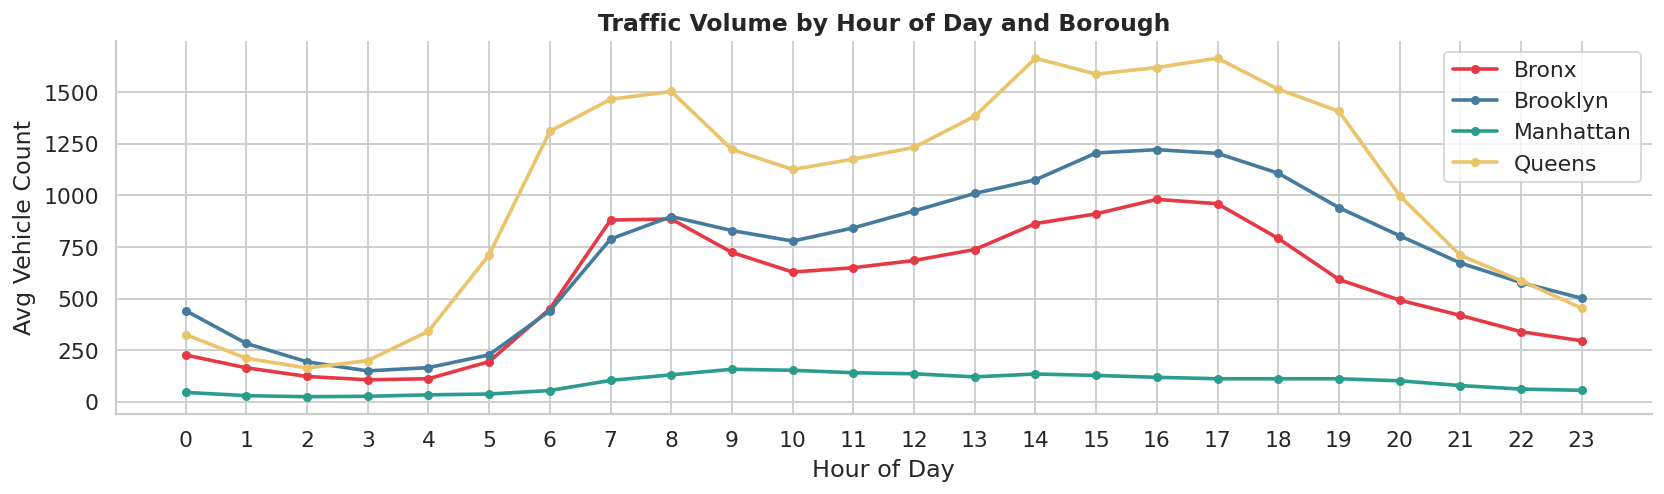

In [22]:
# ── 6b: Traffic by hour of day ────────────────────────────────────────────────
section("6b — Traffic Volume by Hour of Day")

traffic_hourly = (
    df.filter(F.col("traffic_available") == True)
      .groupBy("borough", "hour_of_day")
      .agg(F.round(F.avg("traffic_volume"), 0).alias("avg_volume"))
      .orderBy("borough", "hour_of_day")
      .toPandas()
)

fig, ax = plt.subplots(figsize=(13, 4))
for borough in traffic_hourly["borough"].unique():
    subset = traffic_hourly[traffic_hourly["borough"] == borough]
    ax.plot(subset["hour_of_day"], subset["avg_volume"],
            label=borough, color=BOROUGH_COLORS.get(borough, "#aaa"),
            linewidth=2, marker="o", markersize=4)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Avg Vehicle Count")
ax.set_xticks(range(0, 24))
ax.legend()
plt.title("Traffic Volume by Hour of Day and Borough", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Section 7 — Bivariate Relationships
The core of the research question: how do weather, complaints, and traffic interact?

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 26, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  7b — Temperature vs Complaint Count (Scatter)
═════════════════════════════════════════════════════════════════


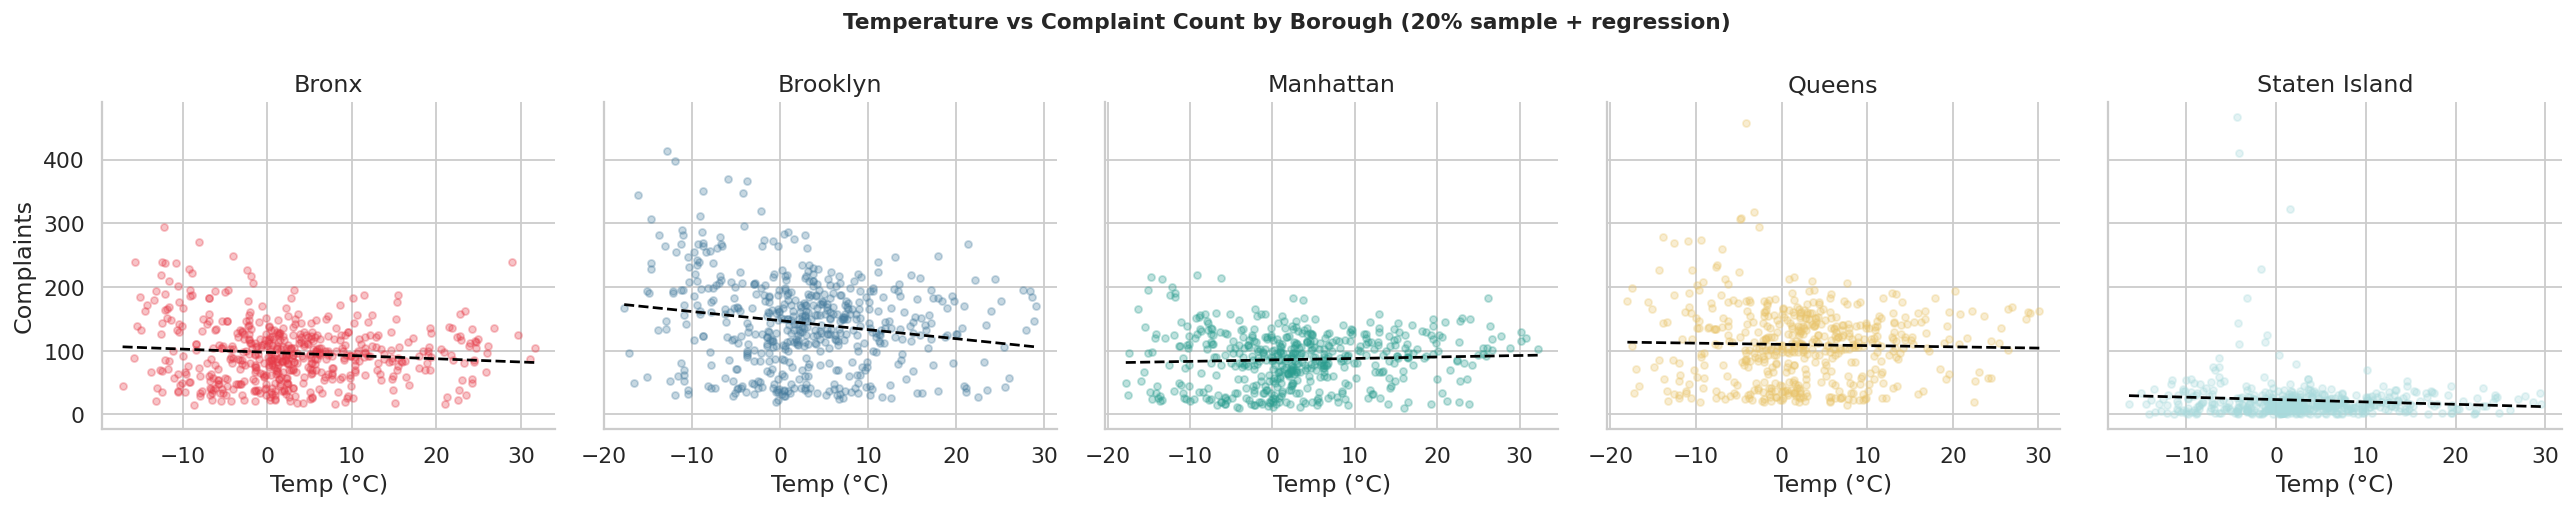

In [23]:
# ── 7b: Temperature vs complaints — scatter with regression line ──────────────
section("7b — Temperature vs Complaint Count (Scatter)")

scatter_pd = (
    df.filter(
        (F.col("complaints_available") == True) &
        (F.col("temperature_2m").isNotNull())
    )
    .select("borough", "temperature_2m", "complaint_count", "weather_category")
    .sample(fraction=0.2, seed=42)
    .toPandas()
)

fig, axes = plt.subplots(1, len(scatter_pd["borough"].unique()),
                         figsize=(4 * len(scatter_pd["borough"].unique()), 4),
                         sharey=True)
if not hasattr(axes, "__len__"):
    axes = [axes]

for ax, (borough, color) in zip(axes, BOROUGH_COLORS.items()):
    subset = scatter_pd[scatter_pd["borough"] == borough]
    if subset.empty:
        ax.set_title(borough)
        continue
    ax.scatter(subset["temperature_2m"], subset["complaint_count"],
               alpha=0.3, s=15, color=color)
    # Regression line
    z = np.polyfit(subset["temperature_2m"], subset["complaint_count"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(subset["temperature_2m"].min(), subset["temperature_2m"].max(), 100)
    ax.plot(x_line, p(x_line), color="black", linewidth=1.5, linestyle="--")
    ax.set_title(borough)
    ax.set_xlabel("Temp (°C)")

axes[0].set_ylabel("Complaints")
plt.suptitle("Temperature vs Complaint Count by Borough (20% sample + regression)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

#### 7b — Insights
- Most boroughs show a **slight negative slope**: as temperature rises, complaints decrease marginally
- The Bronx has the steepest negative slope: cold weather drives significantly more complaints, likely heat/hot water related, makes sense for the borough's older housing

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 27, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  7c — Traffic Volume vs Complaint Count
═════════════════════════════════════════════════════════════════


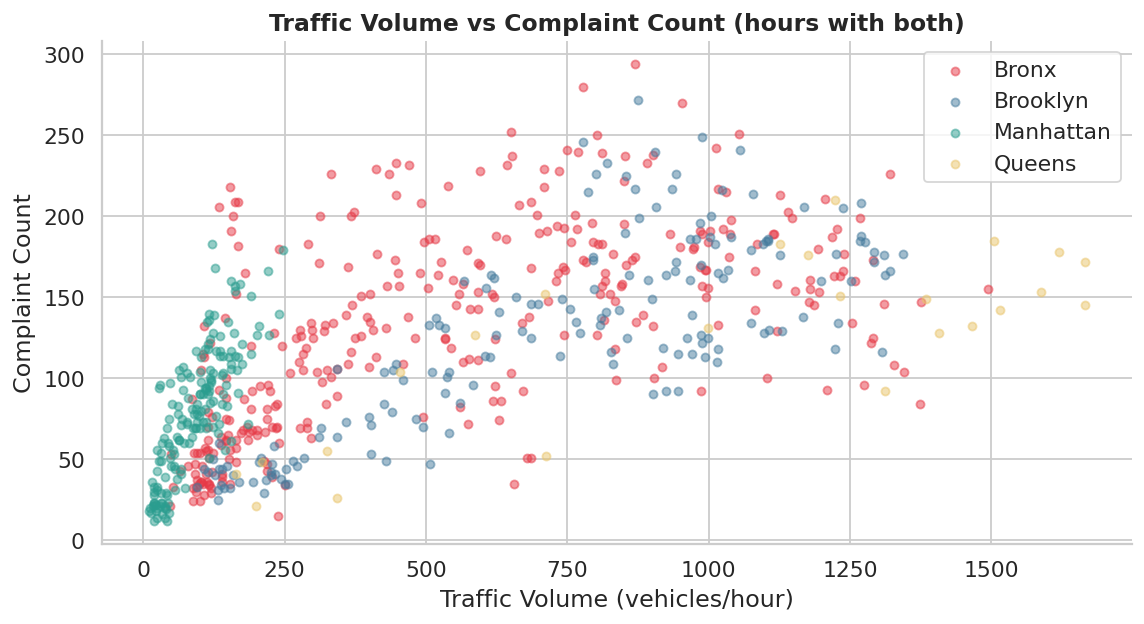

  Pearson correlation (traffic vs complaints): 0.658
  Interpretation: positive relationship —  more traffic → more complaints


In [24]:
# ── 7c: Traffic vs complaints — do they move together or inversely? ────────────
section("7c — Traffic Volume vs Complaint Count")

tv_comp = (
    df.filter(
        (F.col("traffic_available") == True) &
        (F.col("complaints_available") == True)
    )
    .select("borough", "traffic_volume", "complaint_count", "weather_category")
    .toPandas()
)

fig, ax = plt.subplots(figsize=(9, 5))
for borough, color in BOROUGH_COLORS.items():
    subset = tv_comp[tv_comp["borough"] == borough]
    if subset.empty:
        continue
    ax.scatter(subset["traffic_volume"], subset["complaint_count"],
               alpha=0.5, s=20, color=color, label=borough)

ax.set_xlabel("Traffic Volume (vehicles/hour)")
ax.set_ylabel("Complaint Count")
ax.legend()
plt.title("Traffic Volume vs Complaint Count (hours with both)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Pearson correlation
corr = tv_comp[["traffic_volume", "complaint_count"]].corr().iloc[0, 1]
print(f"  Pearson correlation (traffic vs complaints): {corr:.3f}")
print(f"  Interpretation: {'positive' if corr > 0 else 'negative'} relationship — ",
      "more traffic → more complaints" if corr > 0 else "more traffic → fewer complaints")

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 28, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  7d — Noise vs Street Complaints by Weather Category
═════════════════════════════════════════════════════════════════


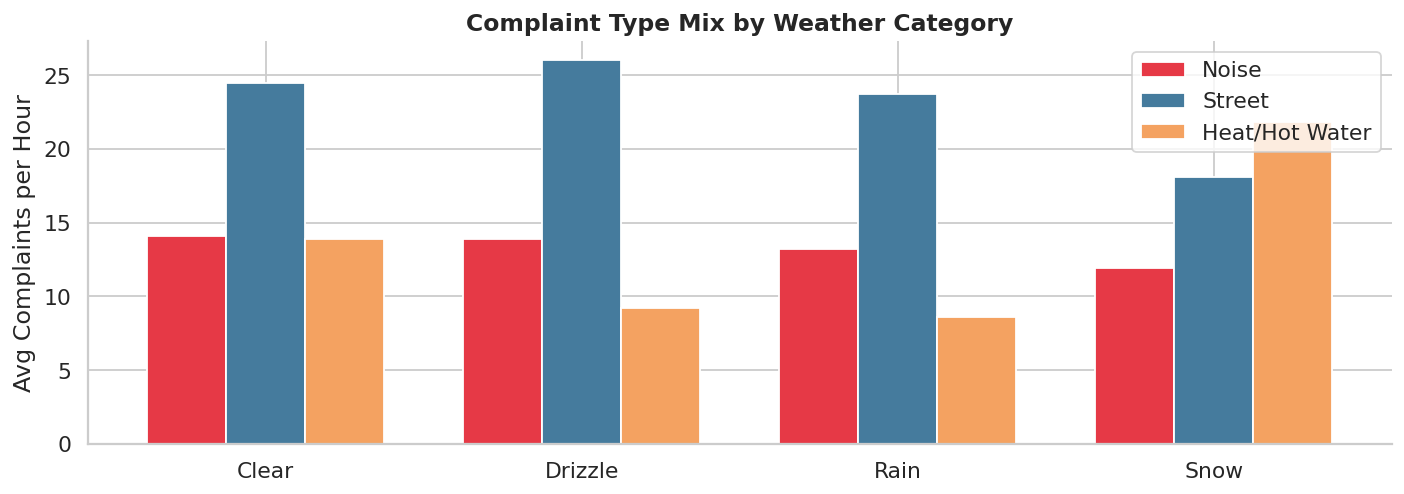

In [25]:
# ── 7d: Noise vs street complaints — do they spike together in bad weather? ───
section("7d — Noise vs Street Complaints by Weather Category")

noise_street = (
    df.filter(F.col("complaints_available") == True)
      .groupBy("weather_category")
      .agg(
          F.round(F.avg("noise_complaints"), 1).alias("avg_noise"),
          F.round(F.avg("street_complaints"), 1).alias("avg_street"),
          F.round(F.avg("heat_hot_water_complaints"), 1).alias("avg_heat"),
      )
      .orderBy("weather_category")
      .toPandas()
)

x = np.arange(len(noise_street))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - width, noise_street["avg_noise"],   width, label="Noise",         color="#e63946")
ax.bar(x,         noise_street["avg_street"],  width, label="Street",        color="#457b9d")
ax.bar(x + width, noise_street["avg_heat"],    width, label="Heat/Hot Water", color="#f4a261")

ax.set_xticks(x)
ax.set_xticklabels(noise_street["weather_category"])
ax.set_ylabel("Avg Complaints per Hour")
ax.legend()
plt.title("Complaint Type Mix by Weather Category", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Section 8 — EDA Summary
Key findings to carry into the report.

In [26]:
# ── Summary stats block — print once, paste into report ──────────────────────
section("EDA Summary")

total_complaints = df.agg(F.sum("complaint_count")).collect()[0][0] or 0
total_traffic    = df.filter(F.col("traffic_available") == True) \
                     .agg(F.sum("traffic_volume")).collect()[0][0] or 0
pct_dry          = df.filter(F.col("precipitation") == 0).count() / n_rows * 100
pct_rain         = df.filter(F.col("weather_category") == "Rain").count() / n_rows * 100
pct_snow         = df.filter(F.col("weather_category") == "Snow").count() / n_rows * 100

print(f"""
  ┌─ Dataset ─────────────────────────────────────────────────
  │  Total rows (borough × hour)  : {n_rows:>12,}
  │  Total 311 complaints         : {int(total_complaints):>12,}
  │  Total vehicle-hours          : {int(total_traffic):>12,}
  ├─ Weather ─────────────────────────────────────────────────
  │  Dry hours                    : {pct_dry:>11.1f}%
  │  Rain hours                   : {pct_rain:>11.1f}%
  │  Snow hours                   : {pct_snow:>11.1f}%
  ├─ Coverage ────────────────────────────────────────────────
  │  Traffic data available        : see Section 1c
  │  Complaint data available      : see Section 1c
  └───────────────────────────────────────────────────────────

  Key findings to investigate further:
  → See Section 7a heatmap for which borough×weather combos spike
  → See Section 7b scatter for temperature–complaint slope per borough
  → See Section 7c correlation for traffic–complaint direction
  → See Section 7e matrix for strongest pairwise correlations
""")

StatementMeta(, b54039b4-7836-4f53-9958-47e002efd2af, 29, Finished, Available, Finished, False)


═════════════════════════════════════════════════════════════════
  EDA Summary
═════════════════════════════════════════════════════════════════

  ┌─ Dataset ─────────────────────────────────────────────────
  │  Total rows (borough × hour)  :       13,320
  │  Total 311 complaints         :    1,165,545
  │  Total vehicle-hours          :      346,244
  ├─ Weather ─────────────────────────────────────────────────
  │  Dry hours                    :        87.7%
  │  Rain hours                   :         1.5%
  │  Snow hours                   :         4.6%
  ├─ Coverage ────────────────────────────────────────────────
  │  Traffic data available        : see Section 1c
  │  Complaint data available      : see Section 1c
  └───────────────────────────────────────────────────────────

  Key findings to investigate further:
  → See Section 7a heatmap for which borough×weather combos spike
  → See Section 7b scatter for temperature–complaint slope per borough
  → See Section 7c correl